<h1>Explain Problem</h1>

<p>In this project, we study an optimization problem in a distributed network. A time update request starts from a given node and must reach the node connected to the NTP server, possibly through intermediate nodes. The goal is to find the route that minimizes the total connection time. To solve this, we model the network as a weighted graph, formulate the problem as a binary optimization task, transform it into a QUBO, and solve it using QAOA, later comparing the results obtained from simulation and real quantum hardware.</p>

<h1>Import libraries</h1>

<h3>Qiskit libraries</h3>

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise.errors import pauli_error, amplitude_damping_error
from IPython.display import display

<h3>Python libraries</h3>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

<h1>Import dataset</h1>

<p>We first load the CSV file and inspect its structure. Each row contains one node, the nodes directly connected to it, and the connection times associated with those links.</p>

In [3]:
df = pd.read_csv('t5-timeupdate.csv', sep=';')
df

,node_name,connected_nodes,connection_times
0,node_1,"node_3,node_4","5.7,10.4"
1,node_2,"node_4,node_ntp","10.2,12.0"
2,node_3,"node_1,node_4,node_ntp","5.7,3.1,35.9"
3,node_4,"node_2,node_3","10.2,3.1"
4,node_ntp,"node_2,node_3","12.0,35.9"


<h1>Build the edge list</h1>

<p>To work with the network more easily, we transform the dataset into an edge list. Each edge will contain a source node, a target node, and the connection time between them.</p>

In [4]:
source_list = []
target_list = []
time_list = []

for i in range(len(df)):
    source_node = df.loc[i, "node_name"]
    connected_nodes = df.loc[i, "connected_nodes"].split(",")
    connection_times = df.loc[i, "connection_times"].split(",")

    for j in range(len(connected_nodes)):
        source_list.append(source_node)
        target_list.append(connected_nodes[j])
        time_list.append(float(connection_times[j]))

edges_df = pd.DataFrame()
edges_df["source"] = source_list
edges_df["target"] = target_list
edges_df["time"] = time_list

edges_df

,source,target,time
0,node_1,node_3,5.7
1,node_1,node_4,10.4
2,node_2,node_4,10.2
3,node_2,node_ntp,12.0
4,node_3,node_1,5.7
5,node_3,node_4,3.1
6,node_3,node_ntp,35.9
7,node_4,node_2,10.2
8,node_4,node_3,3.1
9,node_ntp,node_2,12.0


<h1>Create and draw the graph</h1>

<p>We now create a weighted graph where nodes represent devices in the distributed system and edges represent direct connections weighted by communication time.</p>

In [5]:
G = nx.Graph()

for i in range(len(edges_df)):
    source_node = edges_df.loc[i, "source"]
    target_node = edges_df.loc[i, "target"]
    time_value = edges_df.loc[i, "time"]

    G.add_edge(source_node, target_node, weight=time_value)

print("Nodes:")
print(list(G.nodes))

print("Edges with weights:")
for u, v, data in G.edges(data=True):
    print(u, "--", v, ":", data["weight"])


Nodes:
['node_1', 'node_3', 'node_4', 'node_2', 'node_ntp']
Edges with weights:
node_1 -- node_3 : 5.7
node_1 -- node_4 : 10.4
node_3 -- node_4 : 3.1
node_3 -- node_ntp : 35.9
node_4 -- node_2 : 10.2
node_2 -- node_ntp : 12.0


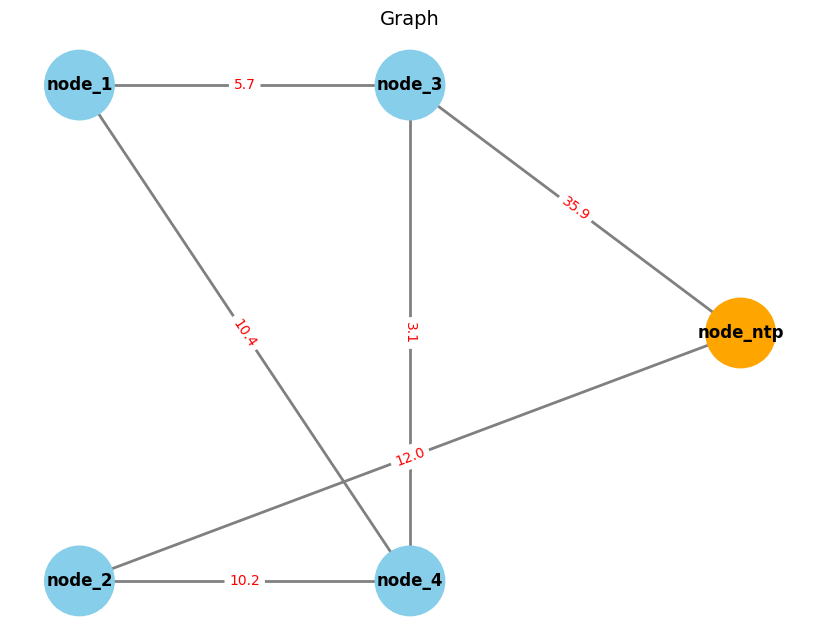

In [6]:
plt.figure(figsize=(8, 6))

pos = {
    "node_1": (0, 2),
    "node_2": (0, 0),
    "node_3": (2, 2),
    "node_4": (2, 0),
    "node_ntp": (4, 1)
}

edge_labels = nx.get_edge_attributes(G, "weight")

node_colors = []
for node in G.nodes():
    if node == "node_ntp":
        node_colors.append("orange")
    else:
        node_colors.append("skyblue")

nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=2500, font_size=12, font_weight="bold", edge_color="gray", width=2)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color="red")

plt.title("Graph", fontsize=14)
plt.show()

<h1>Without weight</h1>

<p>We can also create the same graph without using the connection times. In this case, we only keep the nodes and the connections between them.</p>

In [7]:
G_without_weight = nx.Graph()

for i in range(len(edges_df)):
    source_node = edges_df.loc[i, "source"]
    target_node = edges_df.loc[i, "target"]

    G_without_weight.add_edge(source_node, target_node)

print("Nodes:")
print(list(G_without_weight.nodes))

print("Edges:")
for u, v in G_without_weight.edges():
    print(u, "--", v)


Nodes:
['node_1', 'node_3', 'node_4', 'node_2', 'node_ntp']
Edges:
node_1 -- node_3
node_1 -- node_4
node_3 -- node_4
node_3 -- node_ntp
node_4 -- node_2
node_2 -- node_ntp


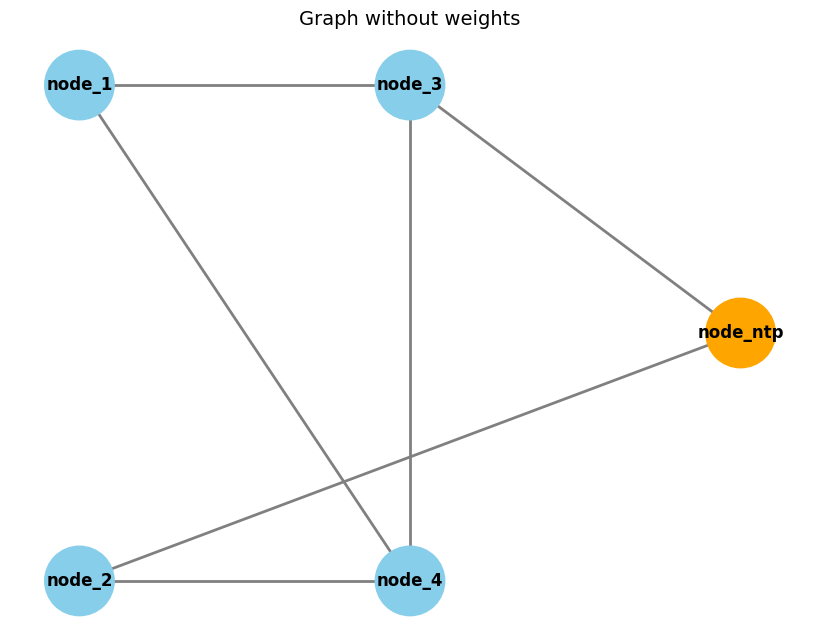

In [8]:
plt.figure(figsize=(8, 6))

pos = {
    "node_1": (0, 2),
    "node_2": (0, 0),
    "node_3": (2, 2),
    "node_4": (2, 0),
    "node_ntp": (4, 1)
}

node_colors = []
for node in G_without_weight.nodes():
    if node == "node_ntp":
        node_colors.append("orange")
    else:
        node_colors.append("skyblue")

nx.draw(G_without_weight, pos, with_labels=True, node_color=node_colors, node_size=2500, font_size=12, font_weight="bold", edge_color="gray", width=2)

plt.title("Graph without weights", fontsize=14)
plt.show()


<h1>Mathematic Formulas</h1>

<h3>Path-choice QUBO with penalty</h3>

In [ ]:
def compute_path_cost(graph, path):
    cost = 0.0

    for index in range(len(path) - 1):
        source = path[index]
        target = path[index + 1]
        cost += graph[source][target]["weight"]

    return cost

def enumerate_candidate_paths(graph, start_node, end_node):
    simple_paths = list(nx.all_simple_paths(graph, source=start_node, target=end_node))
    candidate_paths = []

    for path in simple_paths:
        candidate_paths.append({
            "path": path,
            "cost": compute_path_cost(graph, path)
        })

    candidate_paths.sort(key=lambda candidate: (candidate["cost"], len(candidate["path"])))
    return candidate_paths

def create_path_choice_qubo_matrix(graph, start_node, end_node, penalty_value):
    candidate_paths = enumerate_candidate_paths(graph, start_node, end_node)

    if len(candidate_paths) == 0:
        raise ValueError("No valid path exists between the chosen start and end nodes.")

    variable_names = [f"y_{index}" for index in range(len(candidate_paths))]
    size = len(variable_names)
    Q = np.zeros((size, size))
    constant_term = penalty_value

    for index, candidate in enumerate(candidate_paths):
        Q[index, index] += candidate["cost"] - penalty_value

    for i in range(size):
        for j in range(i + 1, size):
            Q[i, j] += 2 * penalty_value

    Q_df = pd.DataFrame(Q, index=variable_names, columns=variable_names)
    return Q_df, candidate_paths, constant_term


In [ ]:
start_node = "node_1"
end_node = "node_ntp"
penalty_value = 100

Q_matrix, candidate_paths, qubo_constant = create_path_choice_qubo_matrix(
    G,
    start_node,
    end_node,
    penalty_value
)

print("Candidate paths:")
for index, candidate in enumerate(candidate_paths):
    print(f"y{index}: {candidate['path']} (cost = {candidate['cost']})")

print(f"\nPenalty value: {penalty_value}")
print(f"Constant term of the QUBO objective: {qubo_constant}")

Q_matrix


<h3>Cost matrix without penalty terms</h3>

In [ ]:
def create_cost_matrix_without_penalty(candidate_paths):
    variable_names = [f"y_{index}" for index in range(len(candidate_paths))]
    size = len(variable_names)
    matrix = np.zeros((size, size))

    for index, candidate in enumerate(candidate_paths):
        matrix[index, index] = candidate["cost"]

    matrix_df = pd.DataFrame(matrix, index=variable_names, columns=variable_names)
    return matrix_df


In [ ]:
cost_matrix_without_penalty = create_cost_matrix_without_penalty(candidate_paths)
cost_matrix_without_penalty


In [ ]:
classical_shortest_path = nx.shortest_path(G, source=start_node, target=end_node, weight="weight")
classical_shortest_path_cost = nx.shortest_path_length(G, source=start_node, target=end_node, weight="weight")

print("Classical shortest path:", classical_shortest_path)
print("Classical shortest path cost:", classical_shortest_path_cost)


<h1>QAOA</h1>

<p>To run QAOA, we must rewrite the QUBO objective in Ising form. QAOA works with qubits and Pauli operators, so each binary variable x is mapped to a qubit through x = (1 - Z) / 2. After that transformation, the cost function becomes a Hamiltonian made of single-qubit Z terms and two-qubit ZZ terms. The QAOA circuit alternates a cost layer built from that Hamiltonian with a mixer layer built from X rotations.</p>

In [ ]:
from itertools import product
from scipy.optimize import minimize


In [ ]:
def qubo_energy_from_array(binary_array, qubo_df, constant_term=0.0):
    x = np.array(binary_array, dtype=float)
    Q = qubo_df.to_numpy(dtype=float)
    return float(x @ Q @ x + constant_term)

def qubo_energy_from_bitstring(bitstring, qubo_df, constant_term=0.0):
    binary_array = np.array([int(bit) for bit in bitstring[::-1]], dtype=int)
    return qubo_energy_from_array(binary_array, qubo_df, constant_term)

def qubo_to_ising(qubo_df, constant_term=0.0):
    Q = qubo_df.to_numpy(dtype=float)
    num_qubits = Q.shape[0]

    h = np.zeros(num_qubits)
    J = {}
    offset = constant_term

    for i in range(num_qubits):
        qii = Q[i, i]
        offset += qii / 2
        h[i] += -qii / 2

    for i in range(num_qubits):
        for j in range(i + 1, num_qubits):
            qij = Q[i, j] + Q[j, i]

            if abs(qij) > 1e-12:
                offset += qij / 4
                h[i] += -qij / 4
                h[j] += -qij / 4
                J[(i, j)] = qij / 4

    return h, J, offset

def build_qaoa_circuit(h, J, gammas, betas):
    num_qubits = len(h)
    circuit = QuantumCircuit(num_qubits, num_qubits)

    for qubit in range(num_qubits):
        circuit.h(qubit)

    for layer in range(len(gammas)):
        gamma = gammas[layer]
        beta = betas[layer]

        for qubit, coefficient in enumerate(h):
            if abs(coefficient) > 1e-12:
                circuit.rz(2 * gamma * coefficient, qubit)

        for (qubit_i, qubit_j), coefficient in J.items():
            if abs(coefficient) > 1e-12:
                circuit.cx(qubit_i, qubit_j)
                circuit.rz(2 * gamma * coefficient, qubit_j)
                circuit.cx(qubit_i, qubit_j)

        for qubit in range(num_qubits):
            circuit.rx(2 * beta, qubit)

    circuit.measure(range(num_qubits), range(num_qubits))
    return circuit

def counts_to_expected_energy(counts, qubo_df, constant_term=0.0):
    total_shots = sum(counts.values())
    expected_energy = 0.0

    for bitstring, count in counts.items():
        energy = qubo_energy_from_bitstring(bitstring, qubo_df, constant_term)
        expected_energy += energy * count / total_shots

    return expected_energy

def decode_selected_paths(bitstring, candidate_paths):
    binary_array = [int(bit) for bit in bitstring[::-1]]
    selected_paths = []

    for value, candidate in zip(binary_array, candidate_paths):
        if value == 1:
            selected_paths.append(candidate)

    return selected_paths


In [ ]:
num_variables = len(candidate_paths)
best_binary_array = None
best_qubo_energy = float("inf")

for candidate in product([0, 1], repeat=num_variables):
    candidate_energy = qubo_energy_from_array(candidate, Q_matrix, qubo_constant)

    if candidate_energy < best_qubo_energy:
        best_qubo_energy = candidate_energy
        best_binary_array = candidate

best_bitstring = "".join(str(bit) for bit in best_binary_array[::-1])
best_selected_paths = decode_selected_paths(best_bitstring, candidate_paths)
best_path = best_selected_paths[0]["path"] if len(best_selected_paths) == 1 else None
best_path_cost = best_selected_paths[0]["cost"] if len(best_selected_paths) == 1 else None

print("Best QUBO energy found by brute force:", best_qubo_energy)
print("Best bitstring:", best_bitstring)
print("Selected candidate paths:", best_selected_paths)
print("Decoded path:", best_path)
print("Decoded path cost:", best_path_cost)


In [ ]:
p = 2

h, J, ising_offset = qubo_to_ising(Q_matrix, qubo_constant)
simulator = AerSimulator()
shots_for_optimization = 4000

def qaoa_objective(parameters):
    gammas = parameters[:p]
    betas = parameters[p:]
    circuit = build_qaoa_circuit(h, J, gammas, betas)
    compiled_circuit = transpile(circuit, simulator)
    result = simulator.run(compiled_circuit, shots=shots_for_optimization).result()
    counts = result.get_counts()
    return counts_to_expected_energy(counts, Q_matrix, qubo_constant)

initial_parameters = np.array([0.5, 0.7, 0.8, 0.6])
optimization_result = minimize(qaoa_objective, initial_parameters, method="COBYLA")

best_parameters = optimization_result.x
best_gammas = best_parameters[:p]
best_betas = best_parameters[p:]

print("Optimization success:", optimization_result.success)
print("Best gammas:", best_gammas)
print("Best betas:", best_betas)
print("Best estimated expectation value:", optimization_result.fun)


In [ ]:
shots_for_final_run = 8000
best_qaoa_circuit = build_qaoa_circuit(h, J, best_gammas, best_betas)
compiled_best_qaoa_circuit = transpile(best_qaoa_circuit, simulator)
final_result = simulator.run(compiled_best_qaoa_circuit, shots=shots_for_final_run).result()
final_counts = final_result.get_counts()

sorted_counts = sorted(final_counts.items(), key=lambda item: item[1], reverse=True)
best_measured_bitstring, best_measured_count = sorted_counts[0]
best_measured_paths = decode_selected_paths(best_measured_bitstring, candidate_paths)
best_measured_path = best_measured_paths[0]["path"] if len(best_measured_paths) == 1 else None
best_measured_path_cost = best_measured_paths[0]["cost"] if len(best_measured_paths) == 1 else None
best_measured_energy = qubo_energy_from_bitstring(best_measured_bitstring, Q_matrix, qubo_constant)

print("Most frequent bitstring:", best_measured_bitstring)
print("Counts of most frequent bitstring:", best_measured_count)
print("QUBO energy of most frequent bitstring:", best_measured_energy)
print("Selected candidate paths:", best_measured_paths)
print("Decoded path:", best_measured_path)
print("Decoded path cost:", best_measured_path_cost)

plot_histogram(dict(sorted_counts[:10]))
